In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:

daily = pd.read_csv('../data/processed/daily_features.csv', parse_dates=['ActivityDate'])
worn = daily[daily['is_worn']]
hourly = pd.read_csv('../data/processed/hourly_pattern.csv', parse_dates=['ActivityHour'])
hourly['Hour'] = hourly['ActivityHour'].dt.hour
hourly['IsWeekend'] = hourly['ActivityHour'].dt.dayofweek >= 5
user_summary = pd.read_csv('../data/processed/user_summary.csv')

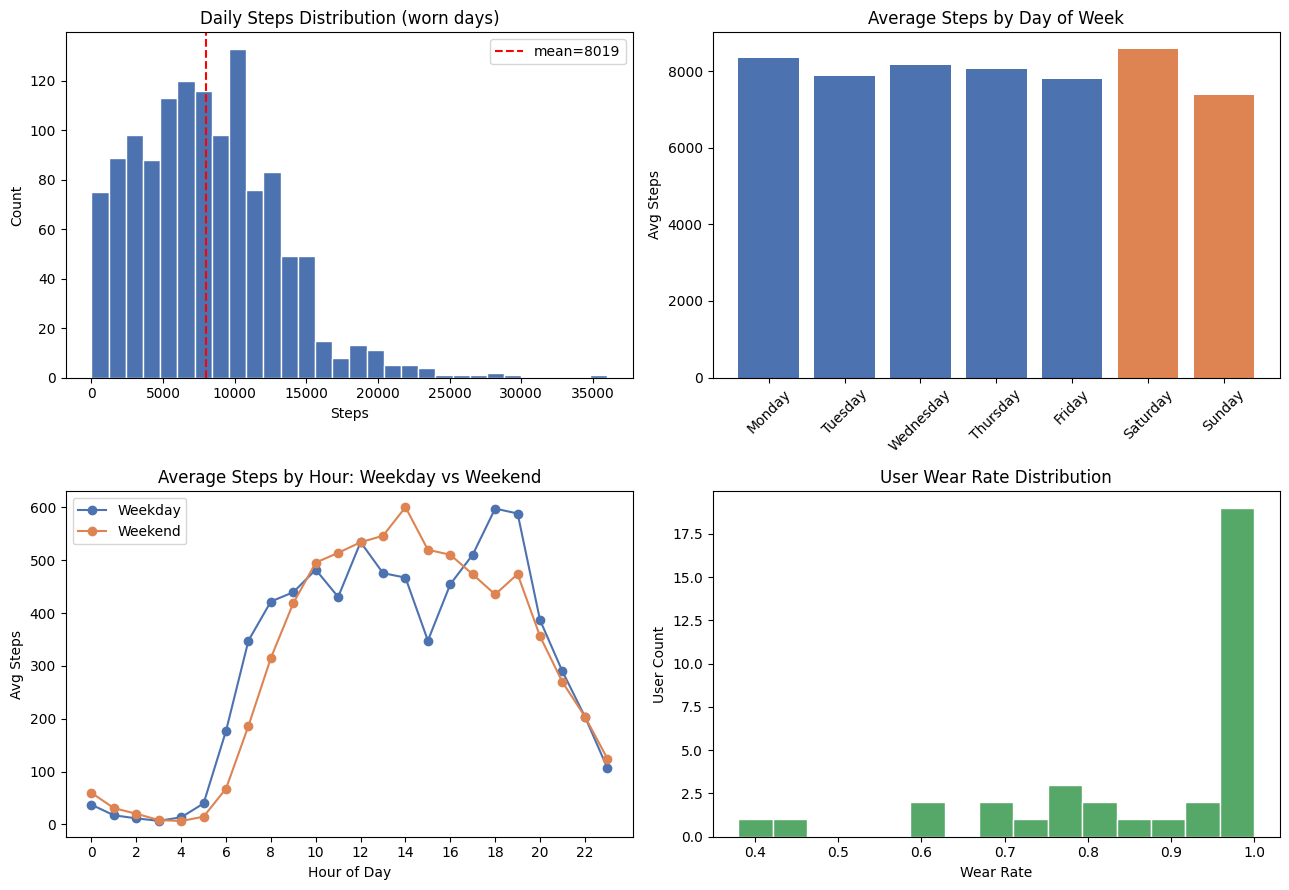

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

axes[0,0].hist(worn['TotalSteps'], bins=30, color='#4C72B0', edgecolor='white')
axes[0,0].axvline(worn['TotalSteps'].mean(), color='red', linestyle='--',
                   label=f"mean={worn['TotalSteps'].mean():.0f}")
axes[0,0].set_title('Daily Steps Distribution (worn days)')
axes[0,0].set_xlabel('Steps'); axes[0,0].set_ylabel('Count'); axes[0,0].legend()

order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
wd = worn.groupby('weekday')['TotalSteps'].mean().reindex(order)
colors = ['#4C72B0']*5 + ['#DD8452']*2
axes[0,1].bar(wd.index, wd.values, color=colors)
axes[0,1].set_title('Average Steps by Day of Week')
axes[0,1].set_ylabel('Avg Steps'); axes[0,1].tick_params(axis='x', rotation=45)

pivot = hourly.groupby(['IsWeekend','Hour'])['StepTotal'].mean().unstack(0)
axes[1,0].plot(pivot.index, pivot[False], marker='o', label='Weekday', color='#4C72B0')
axes[1,0].plot(pivot.index, pivot[True], marker='o', label='Weekend', color='#DD8452')
axes[1,0].set_title('Average Steps by Hour: Weekday vs Weekend')
axes[1,0].set_xlabel('Hour of Day'); axes[1,0].set_ylabel('Avg Steps'); axes[1,0].legend()
axes[1,0].set_xticks(range(0,24,2))

axes[1,1].hist(user_summary['WearRate'], bins=15, color='#55A868', edgecolor='white')
axes[1,1].set_title('User Wear Rate Distribution')
axes[1,1].set_xlabel('Wear Rate'); axes[1,1].set_ylabel('User Count')

plt.tight_layout()
plt.savefig('../outputs/figures/01_eda_overview.png', dpi=130)
plt.show()

In [4]:
print('사용자 수:', user_summary.shape[0])
print('평균 걸음수:', round(worn['TotalSteps'].mean(),1))
print('요일별 평균 걸음수:')
print(wd.round(0))

사용자 수: 35
평균 걸음수: 8019.1
요일별 평균 걸음수:
weekday
Monday       8336.0
Tuesday      7865.0
Wednesday    8157.0
Thursday     8042.0
Friday       7784.0
Saturday     8580.0
Sunday       7380.0
Name: TotalSteps, dtype: float64
